In [69]:
#!pip install pyDOE
#!pip install tensorflow
#!pip install pydot
#!pip install graphviz

In [70]:
import tensorflow as tf
import numpy as np
from pyDOE import lhs
import matplotlib.pyplot as plt
import pydot
import graphviz

In [71]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

Num GPUs Available:  0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 8309867496145796501
xla_global_id: -1
]


In [72]:
# Initial condition
x0, y0 = 0.9, 0.9

# Boundaries of the computational domain
t0, tfinal = 0.0, 7

In [73]:
a = 2/3
b = 4/3
c = 1
d = 1

In [74]:
v0 = (c * x0) - (d * np.log(x0)) + (b * y0) - (a * np.log(y0))
print(v0)

2.275600859429711


In [75]:
#a = 2/3, b = 4/3, c = 1, d = 1
#t0 = 0, tfinal = 12
#x0 = 0.9, y0 = 0.9

with open('LV 2,3 4,3 1 1 0.9 0.9 0 12 0.0001.npy', 'rb') as f:

    points = np.load(f)
    
xpoints = points[0]
ypoints = points[1]

In [76]:
# Define the normalization layer
class Normalize(tf.keras.layers.Layer):
  def __init__(self, xmin, xmax, name=None, **kwargs):
    super(Normalize, self).__init__(name=name)
    self.xmin = xmin
    self.xmax = xmax
    super(Normalize, self).__init__(**kwargs)

  def call(self, inputs):
    return 2.0*(inputs-self.xmin)/(self.xmax-self.xmin)-1.0

  def get_config(self):
    config = super(Normalize, self).get_config()
    config.update({'xmin': self.xmin, 'xmax': self.xmax})
    return config

In [77]:
# Define the network
def build_model(nr_units=40, nr_layers=4, summary=False):

  inp = b = tf.keras.layers.Input(shape=(1,))
  b = Normalize(t0, tfinal)(b)

  for i in range(nr_layers):
    b = tf.keras.layers.Dense(nr_units, activation='tanh')(b)
    print("b", b)
  outx = tf.keras.layers.Dense(1, activation='linear')(b)
  outy = tf.keras.layers.Dense(1, activation='linear')(b)

  model = tf.keras.models.Model(inp, [outx, outy])
  
  if summary:
    model.summary()

  return model

Model: "model_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 3)]               0         
                                                                 
 dense_51 (Dense)            (None, 2)                 8         
                                                                 
Total params: 8
Trainable params: 8
Non-trainable params: 0
_________________________________________________________________


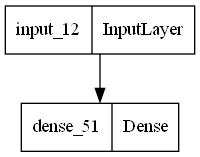

In [78]:
inputs = tf.keras.layers.Input(shape=(3,))
outputs = tf.keras.layers.Dense(2)(inputs)
model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="Adam", loss="mse", metrics=["mae"])
model.metrics_names

model.summary()
tf.keras.utils.plot_model(model)

In [79]:
model = build_model(summary = True)

b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_52/Tanh:0', description="created by layer 'dense_52'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_53/Tanh:0', description="created by layer 'dense_53'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_54/Tanh:0', description="created by layer 'dense_54'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_55/Tanh:0', description="created by layer 'dense_55'")
Model: "model_12"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 1)]          0           []                               
                                                                                     

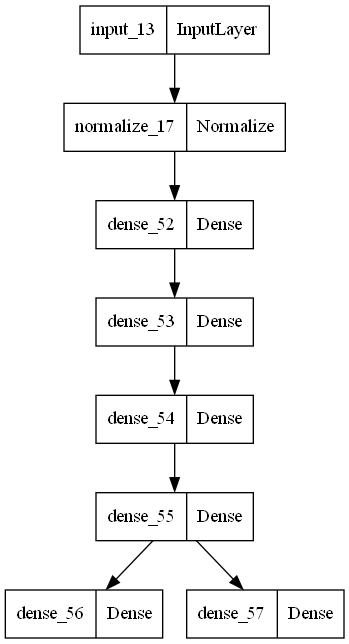

In [80]:
#tf.keras.utils.plot_model(model)

In [81]:
# Define the collocation points over the domain [t_0, t_1]
def defineCollocationPoints(t_bdry, N_pde=100):

    # Sample points where to evaluate the PDE
  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N_pde)

  return ode_points

In [82]:
# Define the collocation points
de_points = defineCollocationPoints([t0, tfinal], 100)

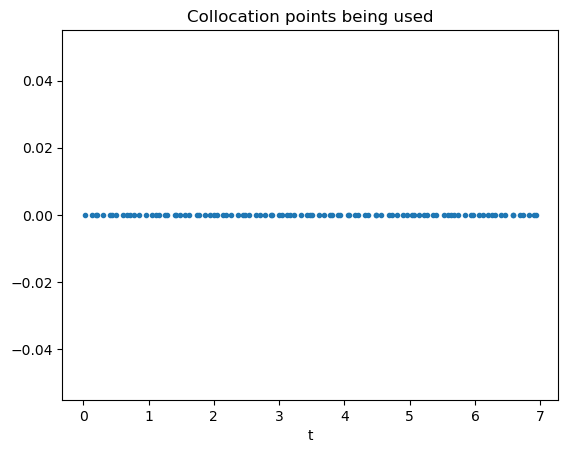

In [83]:
plt.plot(de_points[:,0], 0*de_points[:,0],'.')
plt.xlabel('t')
plt.title('Collocation points being used')
plt.savefig('CollocationPoints1D.png')

In [84]:
# The main training function
@tf.function
def train_network(odes, inits, model, gamma):

    # DE collocation points
    t_de = odes[:,:1]
    #tf.print("t_de", t_de)

    # Initial value points
    t_init, x_init, y_init = inits[:1], inits[1:2], inits[2:]
    #tf.print(t_init, x_init, y_init)

    # Outer gradient for tuning network parameters
    with tf.GradientTape() as tape:

      # Inner gradient for derivatives of u wrt x and t
      with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(t_de)
        print("START MODEL")
        [x, y] = model(t_de, training=True)
        print("END MODEL")

      # Derivative of the neural network solution
      xt = tape2.gradient(x, t_de)
      yt = tape2.gradient(y, t_de)
      
      # Define the differential equation loss  
      eqn1 = xt - (a*x - b*x*y)
      eqn2 = yt - (c*x*y - d*y)
      DEloss = tf.reduce_mean(tf.square(eqn1) + tf.square(eqn2))
                         
      # Define the initial value loss
      [x_init_pred, y_init_pred] = model(t_init, training=True)
      IVloss = tf.reduce_mean(tf.square(x_init_pred - x_init) + tf.square(y_init_pred - y_init))
    
      # Composite loss function
      loss = DEloss + gamma*IVloss

    grads = tape.gradient(loss, model.trainable_variables)
    return DEloss, IVloss, grads

In [85]:
def PINNtrain(de_points, x0, y0, epochs, gamma_val):

  # Total number of collocation points
  N_de = len(de_points)

  # Batch size
  bs_de = N_de//10

  # Weight factor gamma
  gamma = gamma_val

  # Learning rate
  lr_model = 1e-3

  # Initial value
  t_init = np.array([t0]).astype(np.float32)
  x_init = np.array([x0]).astype(np.float32)
  y_init = np.array([y0]).astype(np.float32)

  epoch_loss = np.zeros(epochs)
  nr_batches = 0

  # Generate the tf.Dataset for the initial collocation points
  inits = np.column_stack([t_init, x_init, y_init])
  ds_init = tf.data.Dataset.from_tensor_slices(inits)
  ds_init = ds_init.cache()


  # Generate the tf.Dataset for the differential equations points
  ds_ode = tf.data.Dataset.from_tensor_slices(de_points.astype(np.float32))
  ds_ode = ds_ode.cache().shuffle(N_de).batch(bs_de)

  # Generate entire dataset
  ds = tf.data.Dataset.zip((ds_ode, ds_init))

  ds_list = ds.as_numpy_iterator()

  ds = ds.prefetch(tf.data.experimental.AUTOTUNE)

  # Generate the model
  opt = tf.keras.optimizers.Adam(lr_model)
  model = build_model() 

  # Main training loop
  for i in range(epochs):

    # Training for that epoch
    for (des, inits) in ds:

      # Train the network
      DEloss, IVloss, grads = train_network(des, inits, model, gamma)

      # Gradient step
      opt.apply_gradients(zip(grads, model.trainable_variables))
      
      epoch_loss[i] += DEloss + gamma*IVloss
      nr_batches = nr_batches + 1

    # Get total epoch loss
    epoch_loss[i] = epoch_loss[i]/nr_batches
    nr_batches = 0

    if (np.mod(i, 100)==0):
      print("DE loss, IV loss in {}th epoch: {: 6.4f}, {: 6.4f}.".format(i, DEloss, IVloss))

  return epoch_loss, model

In [86]:
def train_plot(epochs, gamma) :
    
    loss, model = PINNtrain(de_points, x0, y0, epochs, gamma)
    
    # Grid where to evaluate the model
    m = 1000
    t = np.linspace(t0, tfinal, m)
    
    plt.figure(1)
    plt.plot(loss)

    # Model prediction
    [x, y] = model(t)
    
    # Plot the solution
    print(len(x))
    
    plt.figure(2)
    plt.plot(x, y, label = "e = " + str(epochs) + ", gamma = " + str(gamma))
    plt.legend(loc='best')
    plt.plot(xpoints, ypoints, color = 'black')
    
    v = (c * x) - (d * np.log(x)) + (b * y) - (a * np.log(y))
    v = v - v0
    
    plt.figure(3)
    plt.plot([i for i in range(v.shape[0])], v)
    


b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_58/Tanh:0', description="created by layer 'dense_58'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_59/Tanh:0', description="created by layer 'dense_59'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_60/Tanh:0', description="created by layer 'dense_60'")
b KerasTensor(type_spec=TensorSpec(shape=(None, 40), dtype=tf.float32, name=None), name='dense_61/Tanh:0', description="created by layer 'dense_61'")
START MODEL
END MODEL
DE loss, IV loss in 0th epoch:  0.0040,  1.8370.
DE loss, IV loss in 100th epoch:  0.0332,  0.0009.
DE loss, IV loss in 200th epoch:  0.0337,  0.0019.
DE loss, IV loss in 300th epoch:  0.0250,  0.0025.
DE loss, IV loss in 400th epoch:  0.0334,  0.0005.
DE loss, IV loss in 500th epoch:  0.0329,  0.0002.
DE loss, IV loss in 600th epoch:  0.0430,  0.0010.
DE loss, IV loss in 700

DE loss, IV loss in 3400th epoch:  0.0202,  0.0005.
DE loss, IV loss in 3500th epoch:  0.0145,  0.0003.
DE loss, IV loss in 3600th epoch:  0.0031,  0.0002.
DE loss, IV loss in 3700th epoch:  0.0025,  0.0000.
DE loss, IV loss in 3800th epoch:  0.0036,  0.0002.
DE loss, IV loss in 3900th epoch:  0.0018,  0.0007.
DE loss, IV loss in 4000th epoch:  0.0032,  0.0001.
DE loss, IV loss in 4100th epoch:  0.0017,  0.0001.
DE loss, IV loss in 4200th epoch:  0.0022,  0.0001.
DE loss, IV loss in 4300th epoch:  0.0029,  0.0000.
DE loss, IV loss in 4400th epoch:  0.0026,  0.0001.
DE loss, IV loss in 4500th epoch:  0.0023,  0.0002.
DE loss, IV loss in 4600th epoch:  0.0023,  0.0001.
DE loss, IV loss in 4700th epoch:  0.0016,  0.0001.
DE loss, IV loss in 4800th epoch:  0.0018,  0.0002.
DE loss, IV loss in 4900th epoch:  0.0019,  0.0000.
DE loss, IV loss in 5000th epoch:  0.0024,  0.0001.
DE loss, IV loss in 5100th epoch:  0.0024,  0.0002.
DE loss, IV loss in 5200th epoch:  0.0062,  0.0002.
DE loss, IV 

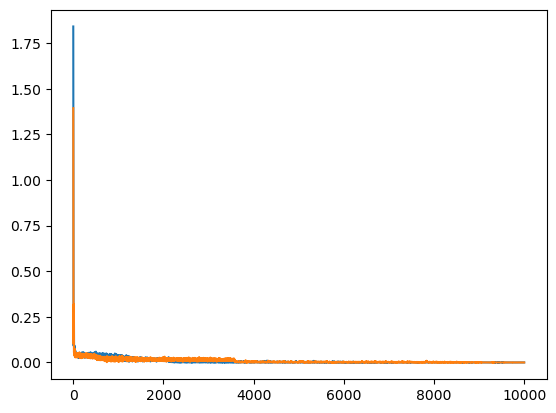

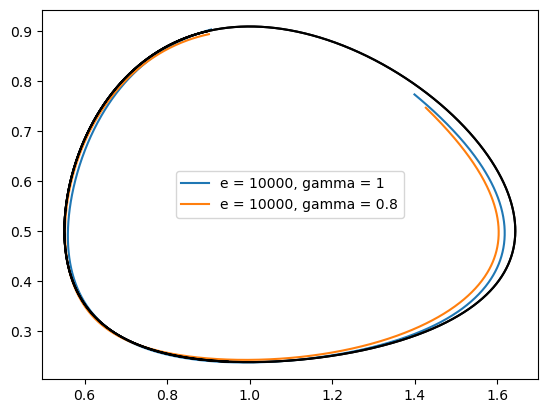

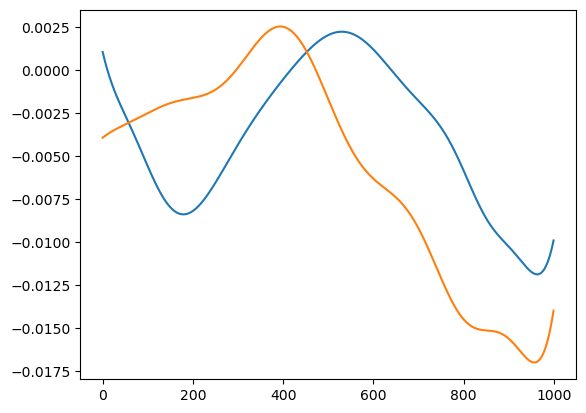

In [87]:
epochs = 10000

train_plot(epochs, 1)
train_plot(epochs, 0.8)

In [88]:
#tfinal epoch first ~0,0 error

#5 4000
#7 8000
#7.5 10000
#8 20000

In [89]:
# Grid where to evaluate the model
m = 1000
t = np.linspace(t0, tfinal, m)

# Model prediction
[x, y] = model(t)

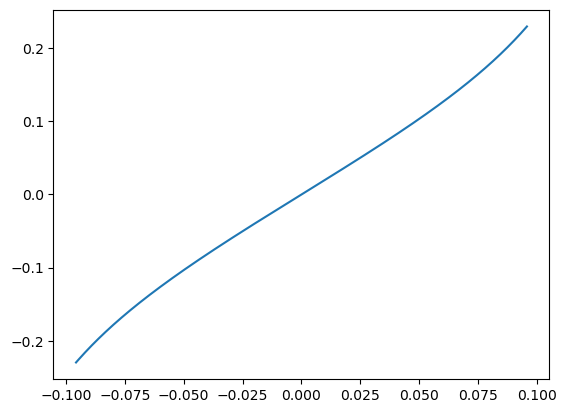

In [90]:
plt.plot(x, y)